In [220]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#file_path = "../root/out_94C50CE8-43B0-AF4D-A8AE-BE0C7EC09B80.root"
file_path = "../root/out_1ED582EB-116D-7D4A-ACD3-B1FDD875261D.root"
#file_path = "../root/out_pbpb_test.root"
#file_path = "../root/out_SIM_ML.root"

file = ROOT.TFile.Open(file_path)
tree = file.Get("jetTree")

n_entries = tree.GetEntries()
print(f"Number of entries in the tree: {n_entries}")

Number of entries in the tree: 136299


In [222]:
hist_lund_prim = ROOT.TH2F("prim_lund", "Average Primary Lund", 100, 0, 10, 100, -10, 10)
hist_lund_sec = ROOT.TH2F("sec_lund", "Average Secondary Lund", 100, 0, 10, 100, -10, 10)
hist_lund_prim_sd = ROOT.TH2F("prim_sd_lund", "Average Primary SD Lund", 100, 0, 10, 100, -10, 10)
hist_lund_sec_sd = ROOT.TH2F("sec_sd_lund", "Average Secondary SD Lund", 100, 0, 10, 100, -10, 10)

list_psi12 = []
list_pt = []

max_x = -float('inf')
min_x = float('inf')
max_y = -float('inf')
min_y = float('inf')
njets_prim = 0
njets_sec = 0
njets_prim_sd = 0
njets_sec_sd = 0
pt_limit = 400
eta_limit = 1.0

for entry in range(n_entries):
    tree.GetEntry(entry)
    for i in range(len(tree.jet_pt)):
        if tree.jet_pt[i] < pt_limit or tree.jetAK[i] == 8 or abs(tree.jet_eta[i]) > eta_limit:
            continue
        list_pt.append(tree.jet_pt[i])
        list_psi12.append(tree.lund_psi12[i])

        for k in range(len(tree.lund_coords_x[i])):
            njets_prim += 1
            x = tree.lund_coords_x[i][k]
            y = tree.lund_coords_y[i][k]
            hist_lund_prim.Fill(x, y)

            if x > max_x:
                max_x = x
            if x < min_x:
                min_x = x
            if y > max_y:
                max_y = y
            if y < min_y:
                min_y = y

        for k in range(len(tree.lund_coords_secondary_x[i])):
            njets_sec += 1
            x = tree.lund_coords_secondary_x[i][k]
            y = tree.lund_coords_secondary_y[i][k]
            hist_lund_sec.Fill(x, y)

        '''
        for k in range(len(tree.lund_coords_x_sd[i])):
            njets_prim_sd += 1
            x = tree.lund_coords_x_sd[i][k]
            y = tree.lund_coords_y_sd[i][k]
            hist_lund_prim_sd.Fill(x, y)

        for k in range(len(tree.lund_coords_x_sd_secondary[i])):
            njets_sec_sd += 1
            x = tree.lund_coords_x_sd_secondary[i][k]
            y = tree.lund_coords_y_sd_secondary[i][k]
            hist_lund_sec_sd.Fill(x, y)
        '''

if min_x < 0:
    min_x = 0
if max_x > 5:
    max_x = 5
if min_y < -2:
    min_y = -2
if max_y > 7:
    max_y = 7

hist_lund_prim.GetXaxis().SetRangeUser(min_x, max_x)
hist_lund_prim.GetYaxis().SetRangeUser(min_y, max_y)

hist_lund_sec.GetXaxis().SetRangeUser(min_x, max_x)
hist_lund_sec.GetYaxis().SetRangeUser(min_y, max_y)

hist_lund_prim_sd.GetXaxis().SetRangeUser(min_x, max_x)
hist_lund_prim_sd.GetYaxis().SetRangeUser(min_y, max_y)

hist_lund_sec_sd.GetXaxis().SetRangeUser(min_x, max_x)
hist_lund_sec_sd.GetYaxis().SetRangeUser(min_y, max_y)

bwx_prim = hist_lund_prim.GetXaxis().GetBinWidth(1)
bwy_prim = hist_lund_prim.GetYaxis().GetBinWidth(1)

bwx_sec = hist_lund_sec.GetXaxis().GetBinWidth(1)
bwy_sec = hist_lund_sec.GetYaxis().GetBinWidth(1)

bwx_prim_sd = hist_lund_prim_sd.GetXaxis().GetBinWidth(1)
bwy_prim_sd = hist_lund_prim_sd.GetYaxis().GetBinWidth(1)

bwx_sec_sd = hist_lund_sec_sd.GetXaxis().GetBinWidth(1)
bwy_sec_sd = hist_lund_sec_sd.GetYaxis().GetBinWidth(1)

#hist_lund_prim.Scale(1.0 / (njets_prim * bwx_prim * bwy_prim))
#hist_lund_sec.Scale(1.0 / (njets_sec * bwx_sec * bwy_sec))
#hist_lund_prim_sd.Scale(1.0 / (njets_prim_sd * bwx_prim_sd * bwy_prim_sd))
#hist_lund_sec_sd.Scale(1.0 / (njets_sec_sd * bwx_sec_sd * bwy_sec_sd))

ROOT.gStyle.SetPalette(ROOT.kRainbow)
#Remove the statistics box
ROOT.gStyle.SetOptStat(0)
c1 = ROOT.TCanvas("c1", "Lund Plane", 800, 600)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1


/var/folders/l_/9rhztf8x7nvc70y6dvv1m8800000gn/T/ipykernel_2822/3216357140.py:29: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


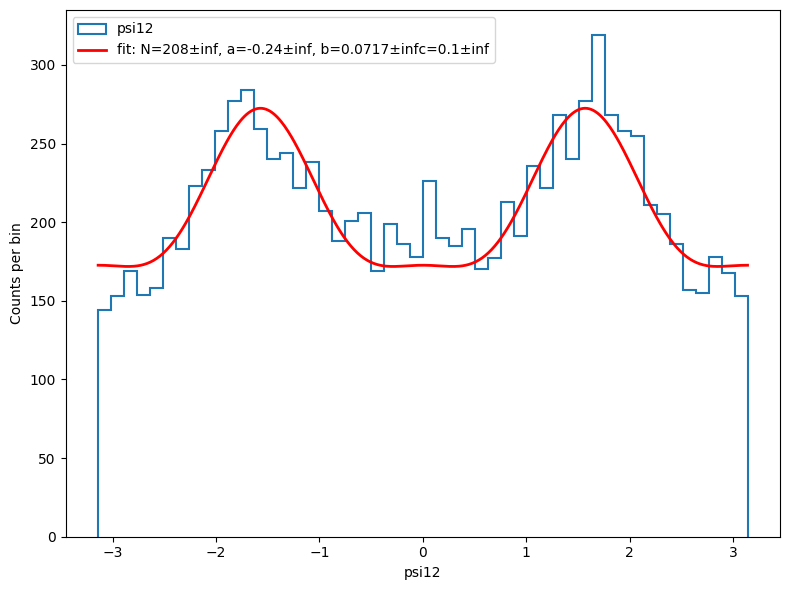

In [223]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

# 0) Clean input (remove NaN/Inf)
psi = np.asarray(list_psi12, dtype=float)
psi = psi[np.isfinite(psi)]

if psi.size == 0:
    raise ValueError("No finite psi12 values to histogram/fit. Check how list_psi12 is filled.")

# 1) Vectorized model (np.cos works with arrays)
def model(x, N, a, b, c):
    return N * (1.0 + a * np.cos(2.0*x) + b * np.cos(4.0 * x)) #+ c * np.cos(3.0 * x))

# 2) Histogram
bins = 50
counts, edges = np.histogram(psi, bins=bins, range=(-np.pi, np.pi))
centers = 0.5 * (edges[:-1] + edges[1:])

# 3) Fit using only bins with nonzero counts (optional but helps)
mask = counts > 0
x = centers[mask]
y = counts[mask]
sigma = np.sqrt(y)  # Poisson

p0 = (np.mean(y), 0.1, 0.1,0.1)

popt, pcov = curve_fit(
    model, x, y, p0=p0,
    sigma=sigma, absolute_sigma=True,
    maxfev=20000
)

# 4) Plot
N_hat, a_hat, b_hat, c_hat = popt
N_err, a_err, b_err, c_err = np.sqrt(np.diag(pcov))

plt.figure(figsize=(8, 6))
plt.hist(psi, bins=bins, range=(-np.pi, np.pi), histtype="step", linewidth=1.5, label="psi12")

xfit = np.linspace(-np.pi, np.pi, 600)
plt.plot(
    xfit, model(xfit, *popt),
    "r-", linewidth=2,
    label=(f"fit: N={N_hat:.3g}±{N_err:.2g}, "
           f"a={a_hat:.3g}±{a_err:.2g}, "
           f"b={b_hat:.3g}±{b_err:.2g}"
           f"c={c_hat:.3g}±{c_err:.2g}")
)

plt.xlabel("psi12")
plt.ylabel("Counts per bin")
plt.legend()
plt.tight_layout()
plt.show()

python ERROR: cannot open image file "imgs/average_primary_lund.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file imgs/average_primary_lund.png


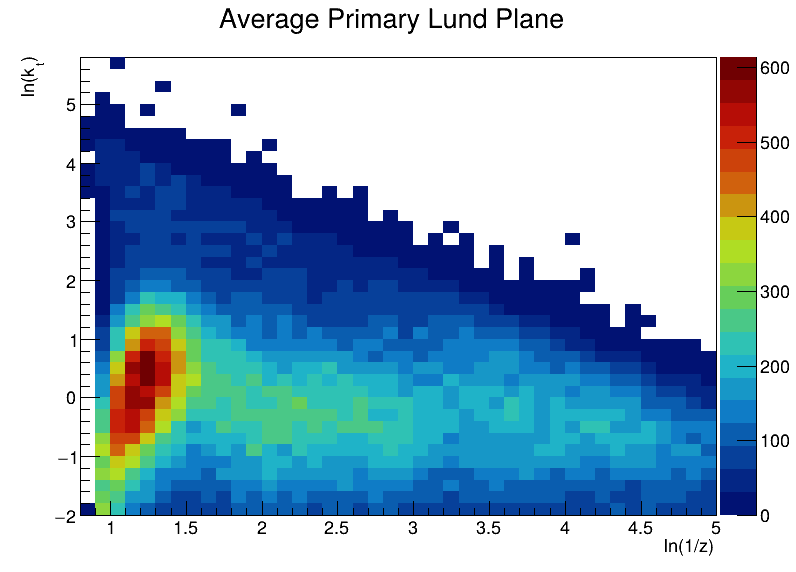

In [224]:
# Draw the histograms
hist_lund_prim.SetTitle("Average Primary Lund Plane;ln(1/z);ln(k_{t})")
hist_lund_prim.Draw("COLZ")
c1.SaveAs("imgs/average_primary_lund.png")

c1.Draw()

python ERROR: cannot open image file "imgs/average_secondary_lund.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file imgs/average_secondary_lund.png


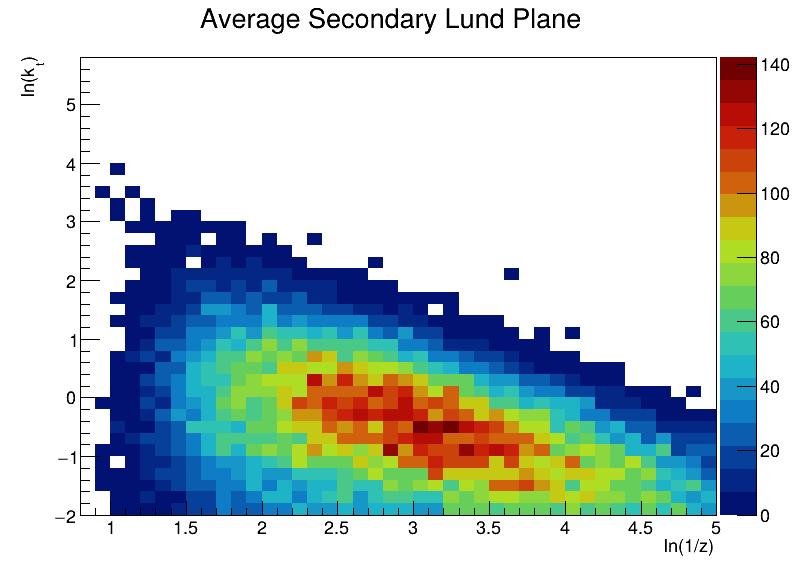

In [225]:
hist_lund_sec.SetTitle("Average Secondary Lund Plane;ln(1/z);ln(k_{t})")
hist_lund_sec.Draw("COLZ")
c1.SaveAs("imgs/average_secondary_lund.png")

c1.Draw()

python ERROR: cannot open image file "imgs/average_primary_lund_zcut.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file imgs/average_primary_lund_zcut.png


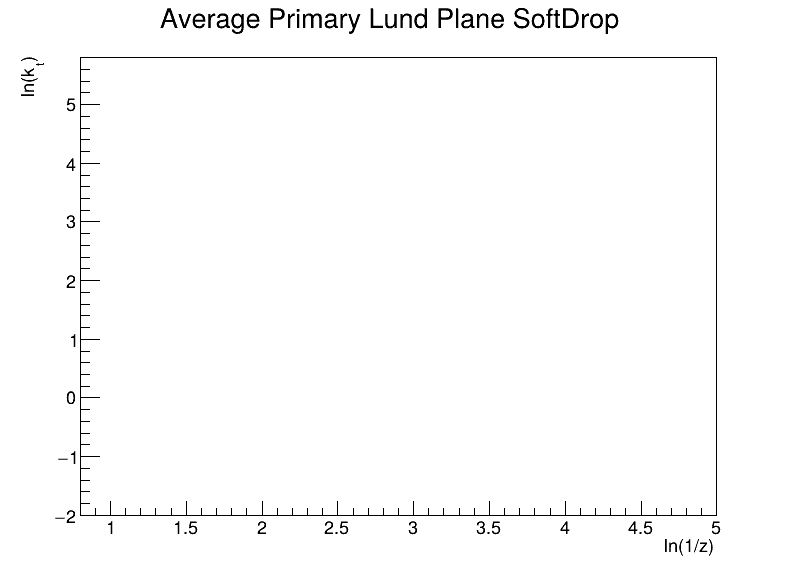

In [226]:
hist_lund_prim_sd.SetTitle("Average Primary Lund Plane SoftDrop;ln(1/z);ln(k_{t})")
hist_lund_prim_sd.Draw("COLZ")
c1.SaveAs("imgs/average_primary_lund_zcut.png")

c1.Draw()

python ERROR: cannot open image file "imgs/average_secondary_lund_zcut.png" for writing. Please check permissions.
Error in <TASImage::WriteImage>: error writing file imgs/average_secondary_lund_zcut.png


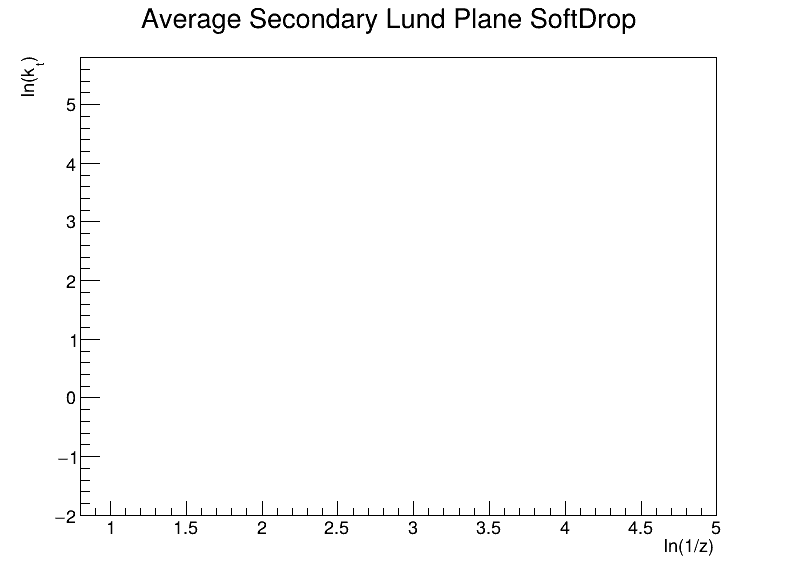

In [227]:
hist_lund_sec_sd.SetTitle("Average Secondary Lund Plane SoftDrop;ln(1/z);ln(k_{t})")
hist_lund_sec_sd.Draw("COLZ")
c1.SaveAs("imgs/average_secondary_lund_zcut.png")

c1.Draw()